# 10 — Validate Against DFT Reference Data

Validates ML predictions against DFT calculations for selected configurations on and near the convex hull.

## Prerequisites / Input files
- `Fe-Mo/FullyCuratedParsedBriefSummary.pkl`
- `Fe-Mo/validation_data/BriefSummary.pkl` — raw AMS DFT results for M/P/δ validation structures
- `Fe-Mo/inchulldft/BriefSummary.pkl.gz` — raw AMS DFT results for δ/R validation structures
- `Fe-Mo/results/voting_regressor_*.pkl` — ensemble models

## Outputs
- Validation metrics and figures in `Fe-Mo/graphs/`



In [1]:
from Tools.DatasetTools.DatasetOperator import Dataset
try:
    from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
except (ImportError, Exception):
    StructSummaryParser = None
from Tools.DatasetTools import EVCurvesTools as EVtools
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

In [2]:
from importlib.machinery import SourceFileLoader

In [3]:
validation_dataset='Fe-Mo/validation_data'

In [4]:
fullvalidationBS = pd.read_pickle(os.path.join(validation_dataset, 'BriefSummary.pkl'))

In [5]:
remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"',

In [6]:
BS = pd.read_pickle('Fe-Mo/FullyCuratedParsedBriefSummary.pkl')

In [7]:
plt.rc('text', usetex=False)

<Axes: ylabel='Frequency'>

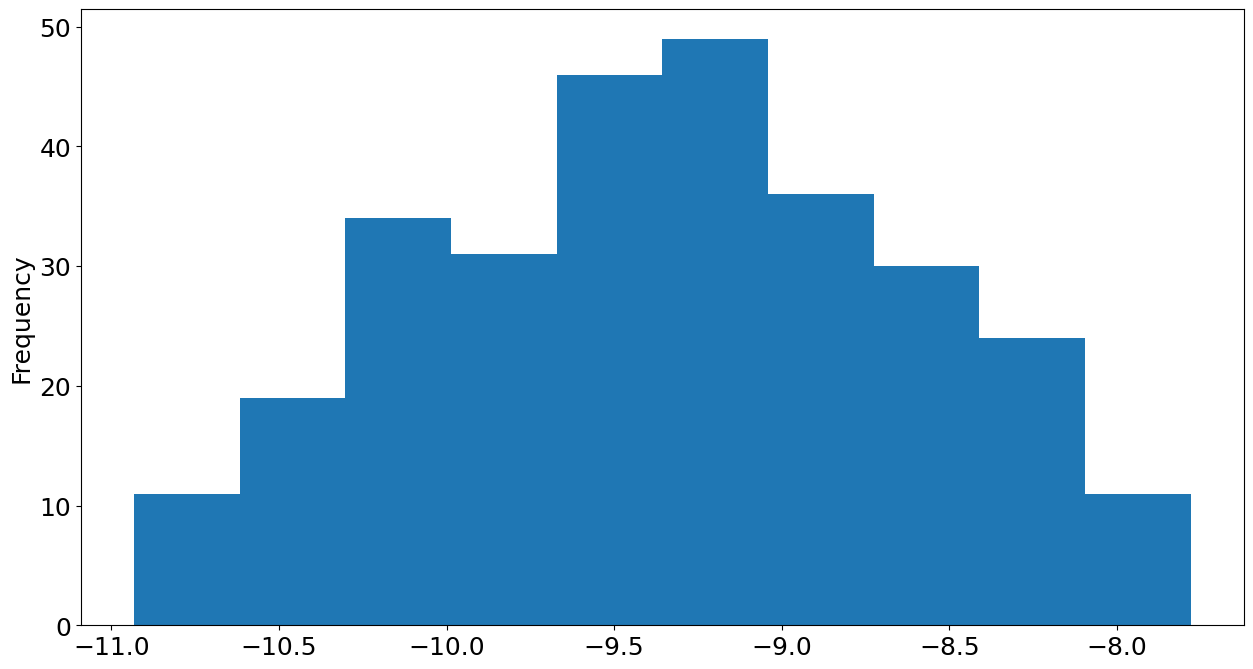

In [8]:
BS['E0'].plot.hist()

In [9]:
validation_samples = fullvalidationBS.index.difference(BS.index)

In [10]:
validation_samples = validation_samples[~validation_samples.str.contains('.FM|sigma')]

In [11]:
len(validation_samples)

14

In [12]:
validationBS = fullvalidationBS.loc[validation_samples]

(array([2., 0., 0., 2., 1., 1., 1., 1., 1., 5.]),
 array([-10.689768  , -10.41926887, -10.14876974,  -9.87827061,
         -9.60777148,  -9.33727234,  -9.06677321,  -8.79627408,
         -8.52577495,  -8.25527582,  -7.98477669]),
 <BarContainer object of 10 artists>)

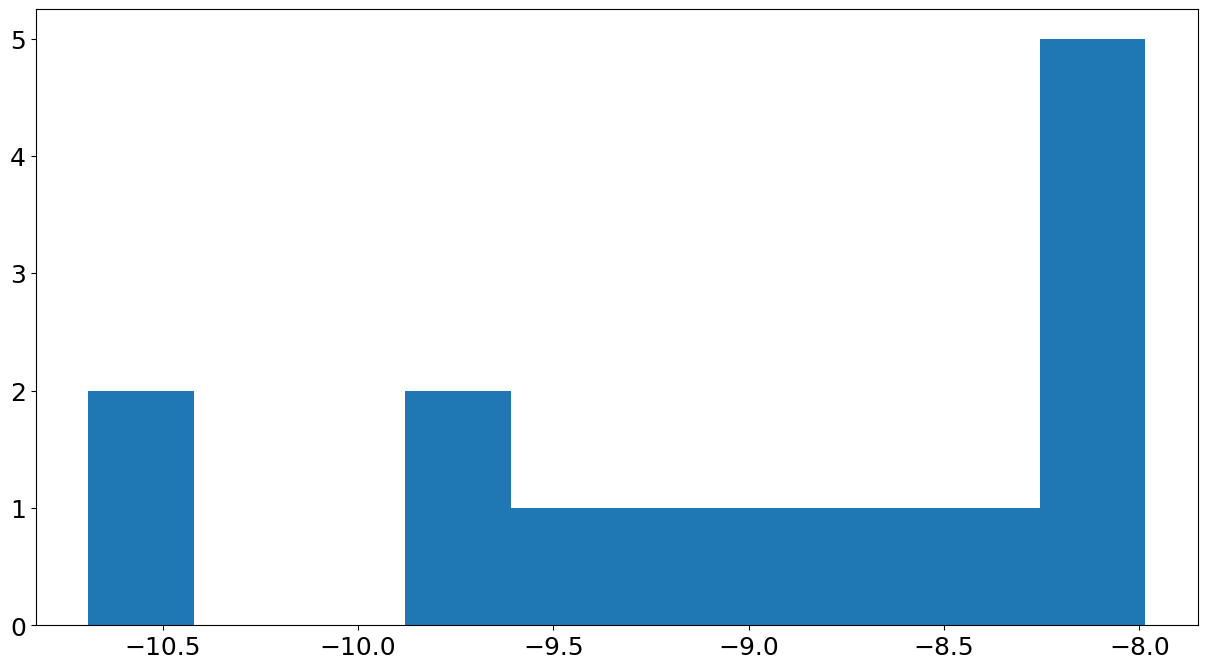

In [13]:
plt.hist(validationBS['E0'])

TODO:
[ ] calculate formation energies for new calculations

In [14]:
validationBS = validationBS[~validationBS.index.str.contains('sigma.[DU]')]

In [15]:
validationBS

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM,NaN,bulk M-ABBAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,263.925712 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,0.056906,0.384615,0.615385
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM,NaN,bulk M-BAAAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,271.174559 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,-0.009650,0.461538,0.538462
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM,NaN,bulk M-AAAAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,276.932244 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,-0.039529,0.538462,0.461538
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM,NaN,bulk M-AAAAAABBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,277.616677 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,-0.025804,0.615385,0.384615
Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM,NaN,bulk M-AAAAAAABBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,276.881627 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,0.018557,0.692308,0.307692
Fe_pv40Mo_sv12.M-AAAAAAABABB.NM,NaN,bulk M-AAAAAAABABB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,276.444886 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,0.054827,0.769231,0.230769
Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM,NaN,bulk M-AAAAAAAAABB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,273.377317 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,0.102519,0.846154,0.153846
Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM,NaN,bulk M-AAAAAAAAAAB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,271.672198 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,0.158369,0.923077,0.076923
Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM,NaN,bulk M-AAAAAAAAABA,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,271.591239 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,0.171643,0.923077,0.076923
Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM,NaN,bulk P-AAAAABAAAAAA,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,275.584610 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,0.141497,0.928571,0.071429


# Check EVcurves

In [16]:
fittedcurvesloc = os.path.join(validation_dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(validation_dataset,'evcurves.json' )
goodnessloc = os.path.join(validation_dataset, 'goodness.json')
force = False

In [17]:
from Tools.DatasetTools import EVCurvesTools as EVtools

In [18]:
#EVtools = SourceFileLoader('EVtools', 'Tools/DatasetTools/EVCurvesTools.py').load_module()

In [19]:
test_indexes = validationBS.index[validationBS.index.str.contains('Mo_sv.*P.NM')]

In [20]:
validationBS.loc[test_indexes]

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Mo_sv56.P.NM,NaN,bulk P,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,1,0.243053,1.0,0.0


In [21]:
import subprocess
from pathlib import Path

mount_root = Path(validation_dataset).resolve()
target_dirs = ["Fe_pv", "Fe_pv-Mo_sv", "Mo_sv"]
target_paths = [(mount_root / directory).resolve() for directory in target_dirs]

def _read_mounts():
    mounts = {}
    with open("/proc/mounts", "r", encoding="utf-8") as mount_file:
        for line in mount_file:
            parts = line.split()
            if len(parts) >= 3:
                mount_point = parts[1].replace("\\040", " ")
                fs_type = parts[2]
                mounts[mount_point] = fs_type
    return mounts

mounts = _read_mounts()
missing_fuse_mounts = [
    path for path in target_paths
    if mounts.get(str(path), "").startswith("fuse") is False
]

if missing_fuse_mounts:
    script_path = mount_root / "mount_data.sh"
    if script_path.exists():
        print("Missing FUSE mounts detected. Running mount_data.sh...")
        subprocess.run(["bash", script_path.name], cwd=str(mount_root), check=True)
    else:
        print("NOTE: Raw validation DFT data not mounted (no mount_data.sh). "
              "EV-curve cells will be skipped.")
else:
    print("All target directories are already mounted with FUSE. Skipping mount_data.sh.")

NOTE: Raw validation DFT data not mounted (no mount_data.sh). EV-curve cells will be skipped.


In [22]:
# NOTE: EV curve fitting requires raw DFT data (not included in this repository).
# Download raw data from NOMAD or contact the authors.
if os.path.exists(os.path.join(validation_dataset, 'Fe_pv', 'briefsummary.dat')):
    if not os.path.exists(fittedcurvesloc) or force:
        if not os.path.exists(evcurvesloc) or force:
            EV = EVtools.Evcurves(Indexes = validationBS.index, atoms=['Fe','Mo'], dataset = validation_dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
            EV.load_evcurves( deltaks = validationBS['deltak'], encuts = validationBS['encut'])
            EVcurves = EV.evcurves
            EVcurves.to_json(evcurvesloc)
        else:
            EVcurves = pd.read_json(evcurvesloc, typ='series')
        goodness, fiteos, r2  = EVtools.get_goodness(EVcurves, r2tol = 1e-6)
        if goodness.map(lambda g: False in g.values()).all():
            goodness = EVtools.invert_goodness(goodness)
        Goodness = pd.Series(goodness)
        Fits = pd.Series(fiteos)
        R2 = pd.Series(r2)
        for index, data in EVcurves.items():
            for key, evcurve in data.items():
                if index in R2.keys():
                    if key in R2[index].keys():
                        data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
        EVcurves.to_json(fittedcurvesloc)
    else:
        print('B')
        EVcurves = pd.read_json(fittedcurvesloc, typ='series')
        R2 = EVtools.get_key_for_curves(EVcurves, 'r2')
        Goodness = EVtools.get_key_for_curves(EVcurves, 'IsGood')
        Fits = EVtools.get_key_for_curves(EVcurves, 'fit')
else:
    # Raw DFT data not available — load pre-computed EV curve fits from tracked JSON
    if os.path.exists(fittedcurvesloc):
        print("NOTE: Raw DFT data not available. Loading pre-computed EV curve fits.")
        EVcurves = pd.read_json(fittedcurvesloc, typ='series')
        R2 = EVtools.get_key_for_curves(EVcurves, 'r2')
        Goodness = EVtools.get_key_for_curves(EVcurves, 'IsGood')
        Fits = EVtools.get_key_for_curves(EVcurves, 'fit')
    else:
        print("WARNING: Neither raw DFT data nor pre-computed EV curves found.")
        print(f"Expected: {fittedcurvesloc}")
        EVcurves = None


NOTE: Raw DFT data not available. Loading pre-computed EV curve fits.


In [23]:
EVcurves

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM                                                         {}
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM                                                         {}
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM                                                        {}
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM                                                         {}
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM                                                        {}
                                                               ...                        
Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM                                                         {}
Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM                                                   {}
Mo_sv56.P.NM                             {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Mo_sv56.delta-BBBBBBBBBBBBBB.NM                                                         {}
Mo_sv56.delta.NM                         {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...

# Recover Predicted values

In [24]:
validationBS.loc[test_indexes]['E0']

Mo_sv56.P.NM   -10.689768
Name: E0, dtype: float64

In [25]:
for index, param_curve in EVcurves[test_indexes].items():
    break

In [26]:
Fits[index]

{'xc=PBE-PAW.E=450.dk=0.020': [-10.6897684165,
  243.2756354233,
  4.3066181768,
  16.2330849116]}

In [27]:
for params, curve in param_curve.items():
    break

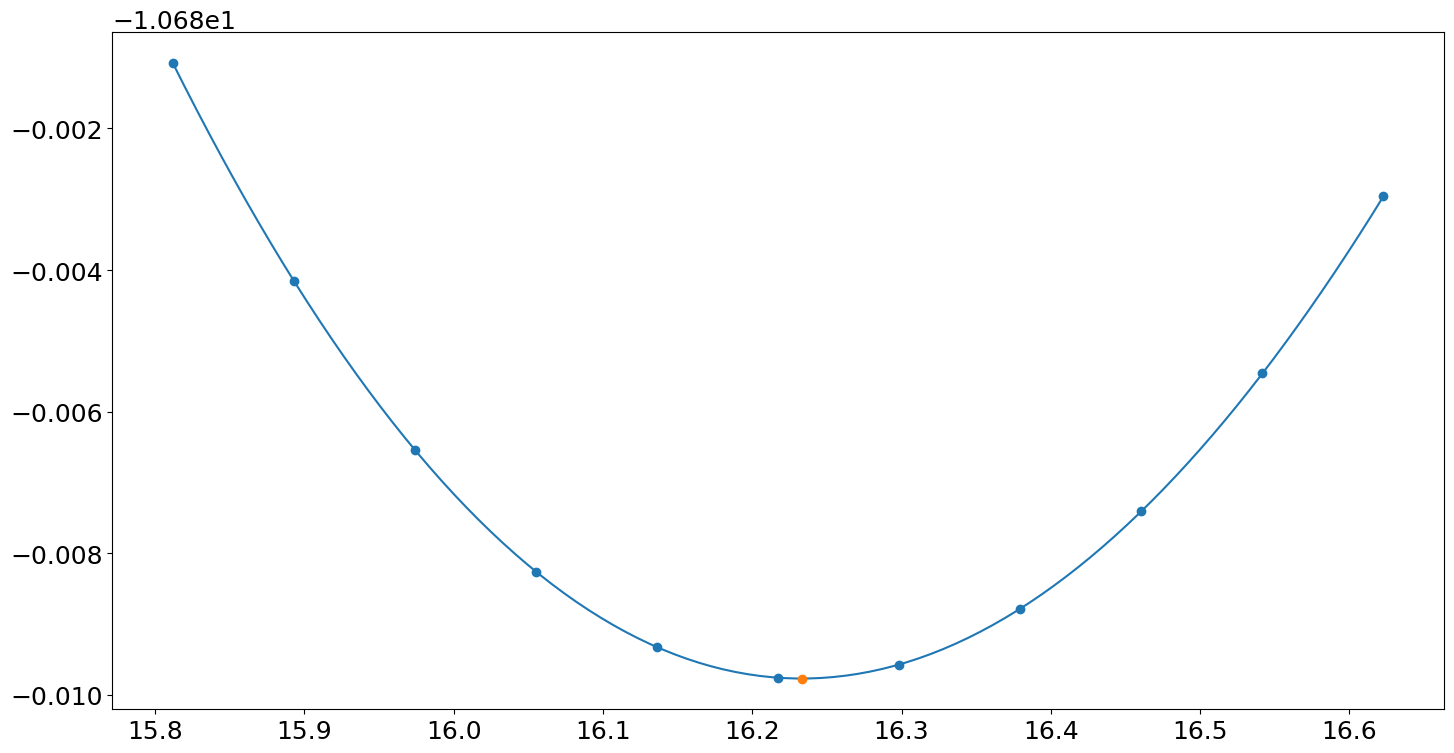

In [28]:
fig, ax = plt.subplots()
EVtools.plot_fitted_curve(curve['evcurve'], Fits[index][params], R2[index][params], ax = ax, fig=fig)
ax.plot([validationBS.loc[index]['V0']], [validationBS.loc[index]['E0']],'o')

In [29]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [30]:
empty_curves = EVcurves[EVcurves.map(lambda c: len(c)==0)].index

In [31]:
EVcurves[empty_curves]

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM           {}
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           {}
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM          {}
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM           {}
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM          {}
Fe_pv16Mo_sv40.delta-BBBBBBBBABAAAB.NM    {}
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM    {}
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           {}
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           {}
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           {}
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          {}
Fe_pv20Mo_sv36.delta-BBBBBBBBAAAAAB.NM    {}
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM    {}
Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM          {}
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM    {}
Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM    {}
Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM          {}
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM    {}
Fe_pv28Mo_sv28.delta-BBBABBBBAAAAAA.NM    {}
Fe_pv28Mo_sv28.delta-BBBBBBBAAAAAAA.NM    {}
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM           {}
Fe_pv32Mo_sv24.P-AAABBBAAABAB.NM          {}
Fe_pv32Mo_

In [32]:
complete_curves = EVcurves.index.difference(empty_curves)

Only take the validationBS with given EV curves

In [33]:
validationBS = validationBS.loc[complete_curves]
EVcurves = EVcurves[complete_curves]
R2 = R2[complete_curves]
Fits = Fits[complete_curves]

# Get dataframes 

In [34]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')

In [35]:
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')

In [36]:
Better_evcurves = {}

In [37]:
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

/tmp/ipykernel_242265/1452277664.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
/tmp/ipykernel_242265/1452277664.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]


In [38]:
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')

In [39]:
ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')

In [40]:
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})

In [41]:
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

Text(0.5, 1.0, '4 Good Samples')

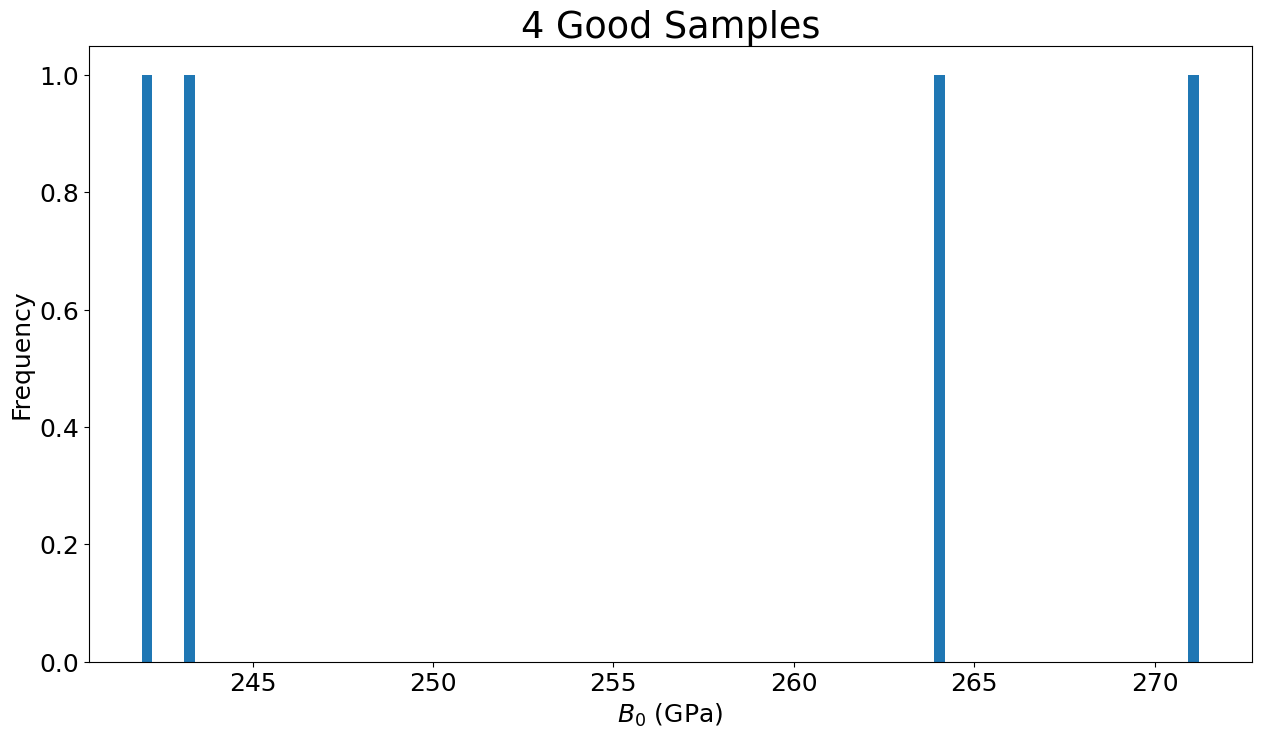

In [42]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [43]:
Better_evcurves_df.shape

(14, 6)

In [44]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [45]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [46]:
indexofbadsamples

Index(['Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM', 'Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM',
       'Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM', 'Fe_pv40Mo_sv12.M-AAAAAAABABB.NM',
       'Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM', 'Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM',
       'Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM', 'Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM',
       'Fe_pv56.P.NM', 'Fe_pv56.delta.NM'],
      dtype='object')

In [47]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

Text(0.5, 1.0, '4 Good Samples')

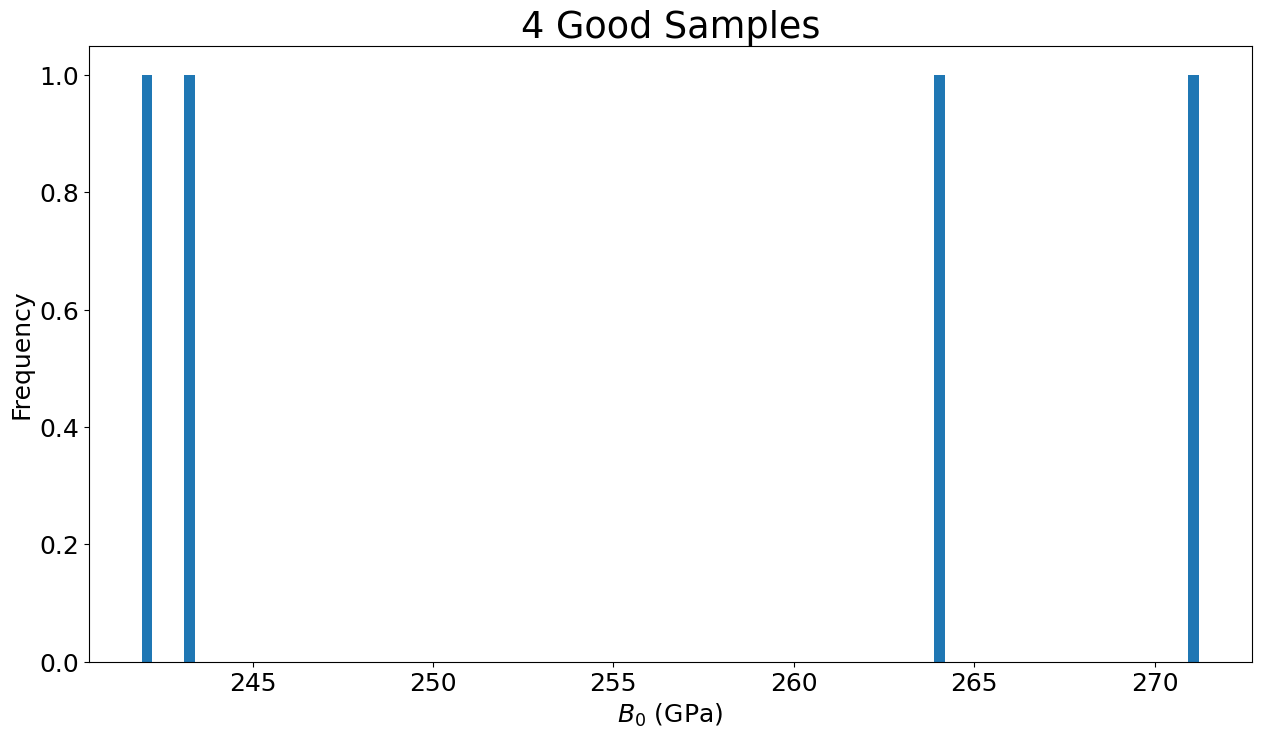

In [48]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [49]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [50]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [51]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

/tmp/ipykernel_242265/816183106.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=f'{NGOOD} good samples')


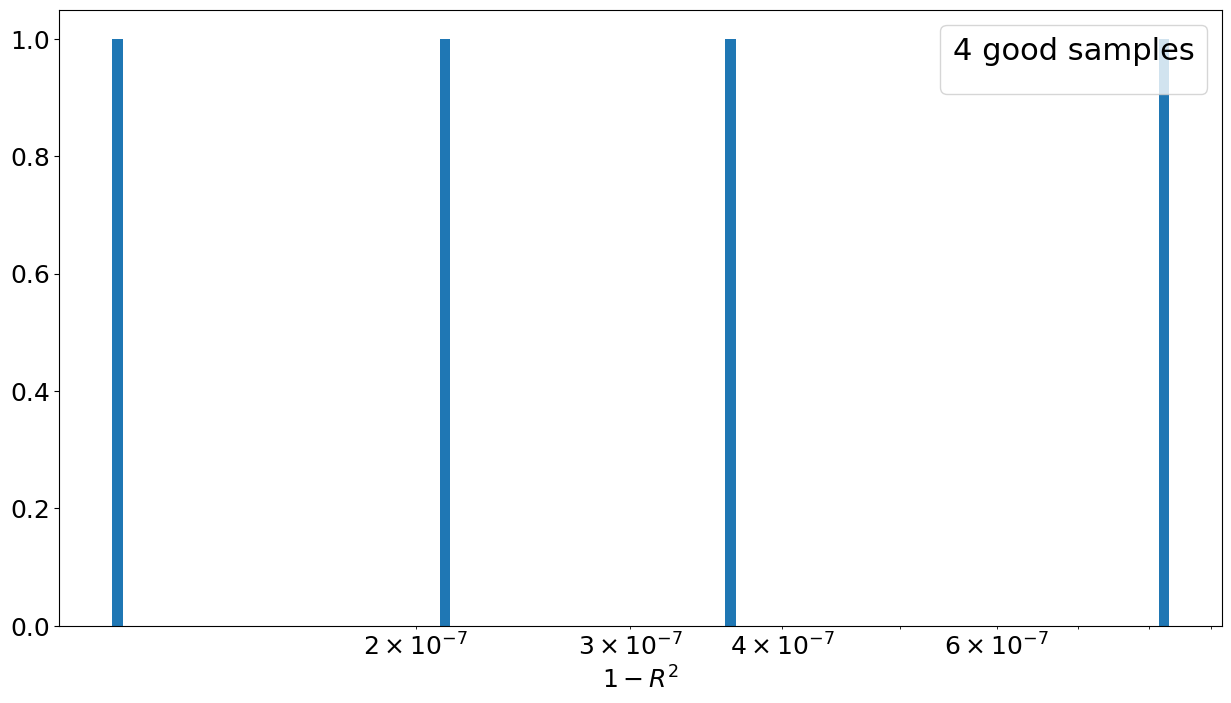

In [52]:
hist, bins = np.histogram(1-Better_evcurves_df.r2[indexofgoodsamples], bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
fig, ax = plt.subplots()
ax.hist(1-Better_evcurves_df.r2[indexofgoodsamples], bins=logbins)
Better_evcurves_df.r2[indexofgoodsamples]
ax.set_xscale('log')
xlabel = ax.set_xlabel('$1-R^2$')
NGOOD = len(indexofgoodsamples)
ax.legend(title=f'{NGOOD} good samples')

# Differences between fits and available data for bad samples

In [53]:
diff_fit_to_dataset = ((validationBS.B0[indexofbadsamples] - fit_results_df.B_murn[indexofbadsamples])/fit_results_df.B_murn[indexofbadsamples]).abs().to_frame().rename(columns={0: 'B0'})

In [54]:
diff_fit_to_dataset['E0'] = ((validationBS.E0[indexofbadsamples] - fit_results_df.E_murn[indexofbadsamples])/fit_results_df.E_murn[indexofbadsamples]).abs().dropna()

In [55]:
diff_fit_to_dataset['V0'] = ((validationBS.V0[indexofbadsamples] - fit_results_df.V_murn[indexofbadsamples])/fit_results_df.V_murn[indexofbadsamples]).abs().dropna()

Text(0.5, 0, '$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

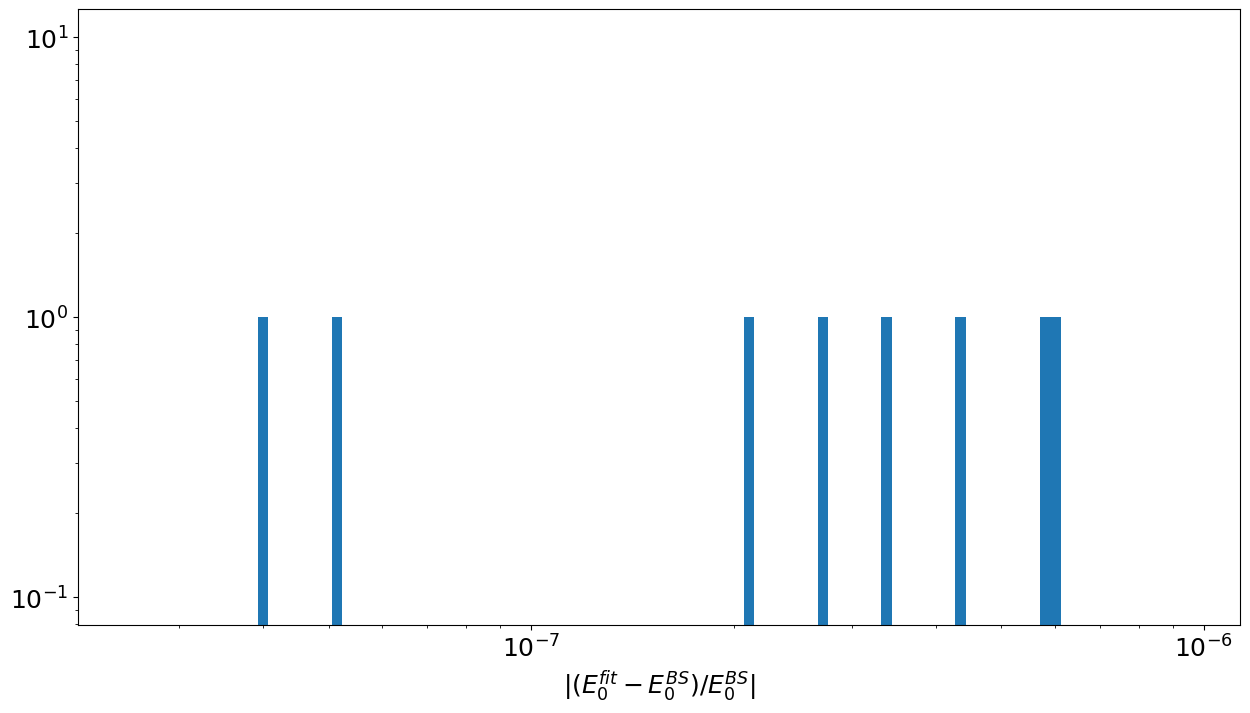

In [56]:
large_diff_E0 = diff_fit_to_dataset.query('E0 > 1e-5').index
fig, ax = plt.subplots()
hist, bins = np.histogram(diff_fit_to_dataset.E0, bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
loghist = plt.hist(diff_fit_to_dataset.E0, bins=logbins)
fig = plt.xscale('log')
fig = plt.yscale('log')
for index in large_diff_E0:
    x = diff_fit_to_dataset.E0[index]
    y = 1
    ax.annotate(index, (x, y), rotation='90')
plt.xlabel(r'$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

# Try to correct the bad fits by removing points 

In [57]:
from importlib.machinery import SourceFileLoader

In [58]:
len(validationBS)

14

In [59]:
len(indexofgoodsamples)

4

In [60]:
len(indexofbadsamples)

10

In [61]:
GoodBS = validationBS.loc[indexofgoodsamples]

In [62]:
from importlib.machinery import SourceFileLoader
find_the_good_curve_inside = SourceFileLoader('find_the_good_curve_inside','Tools/DatasetTools/EVCurvesTools.py').load_module().find_the_good_curve_inside
is_common_sense_evcurve = SourceFileLoader('is_common_sense_evcurve','Tools/DatasetTools/EVCurvesTools.py').load_module().is_common_sense_evcurve
ev_per_angstrom3_to_GPA = 160.21

doexit = False

fixedevcurves = pd.Series([], name='FixedEVcurves')
fixedr2 = pd.Series([], name='FixedR2')
fixedfit = pd.Series([], name='Fixedfit')
tol = 1e-6
now_is_good = []
common_sense_evcurve = []
progress = tqdm(EVcurves[indexofbadsamples].items(), total = len(indexofbadsamples))
for index, paramcurve in progress:
    if index in fixedevcurves.keys():
        continue
    progress.set_description('index')
    if index in GoodBS.index:
        continue
    for paramspec, curvedata in paramcurve.items():
        r2, params_onreduced, reducedv, reducede = find_the_good_curve_inside(curvedata, tol=tol, reset_guess_params = True)
        common_sense_evcurve.append( is_common_sense_evcurve(reducedv, reducede, params_onreduced, unitsofb0='GPa'))
        now_is_good.append( (r2>1-tol) & common_sense_evcurve[-1] )
        progress.set_postfix_str(f'{index}, 1-r2 = {1-r2:.2e}, B0={params_onreduced[1]}, now is good = {now_is_good[-1]}')
        if params_onreduced[1] < 0 and now_is_good:
            raise ValueError('B0 is negative on '+index)
        fixedevcurves[index] = {
            paramspec: {
                'evcurve' :{ 'V' : reducedv , 'E': reducede },
                'ev_fit_results' :  {'E_murn': params_onreduced[0], 'V_murn' : params_onreduced[-1], 'B_murn': params_onreduced[1], 'Bdev_murn' : params_onreduced[2]},
                'r2' : r2,
                'IsGood' : now_is_good[-1],
                'fit': params_onreduced,
                'calc_param' : paramspec
            }
        }

  0%|          | 0/10 [00:00<?, ?it/s]

In [63]:
fixedevcurves

Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv40Mo_sv12.M-AAAAAAABABB.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM     {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv56.P.NM                       {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv56.delta.NM                   {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Name: FixedEVcurves, dtype: object

In [64]:
fixedevcurves_df = pd.DataFrame.from_dict(fixedevcurves.to_dict(), orient='index')

In [65]:
fixedevcurves_df.shape

(10, 1)

In [66]:
Better_fixedevcurves = {}

In [67]:
for index, evcurves in fixedevcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

/tmp/ipykernel_242265/667138312.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
/tmp/ipykernel_242265/667138312.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]


In [68]:
Better_fixedevcurves_df = pd.DataFrame.from_dict(Better_fixedevcurves, orient='index')

In [69]:
fixedR2 = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedR2[index] = {paramspec: curvedata['r2']}

In [70]:
fixedFits = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedFits[index] = {paramspec: curvedata['fit']}

In [71]:
fixed_ev_fit_results = {} #pd.DataFrame([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixed_ev_fit_results[index] = pd.Series(curvedata['ev_fit_results'])
fixed_ev_fit_results_df = pd.DataFrame.from_dict(fixed_ev_fit_results, orient='index')

In [72]:
indexoffixedgoodsamples = Better_fixedevcurves_df.query('IsGood == True').index

In [73]:
indexoffixedbadsamples = Better_fixedevcurves_df.index.difference(indexoffixedgoodsamples)

In [74]:
indexoffixedbadsamples

Index([], dtype='object')

In [75]:
len(indexoffixedgoodsamples) + len(indexofgoodsamples)#+len(indexoffixedbadsamples)

14

In [76]:
finalindexofsamples = indexofgoodsamples.append(indexoffixedgoodsamples)

In [77]:
finalindexofsamples

Index(['Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM', 'Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM',
       'Mo_sv56.P.NM', 'Mo_sv56.delta.NM', 'Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM',
       'Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM', 'Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM',
       'Fe_pv40Mo_sv12.M-AAAAAAABABB.NM', 'Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM',
       'Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM', 'Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM',
       'Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM', 'Fe_pv56.P.NM', 'Fe_pv56.delta.NM'],
      dtype='object')

In [78]:
fixedValidationBS = validationBS.loc[finalindexofsamples]

# Fixed quantities

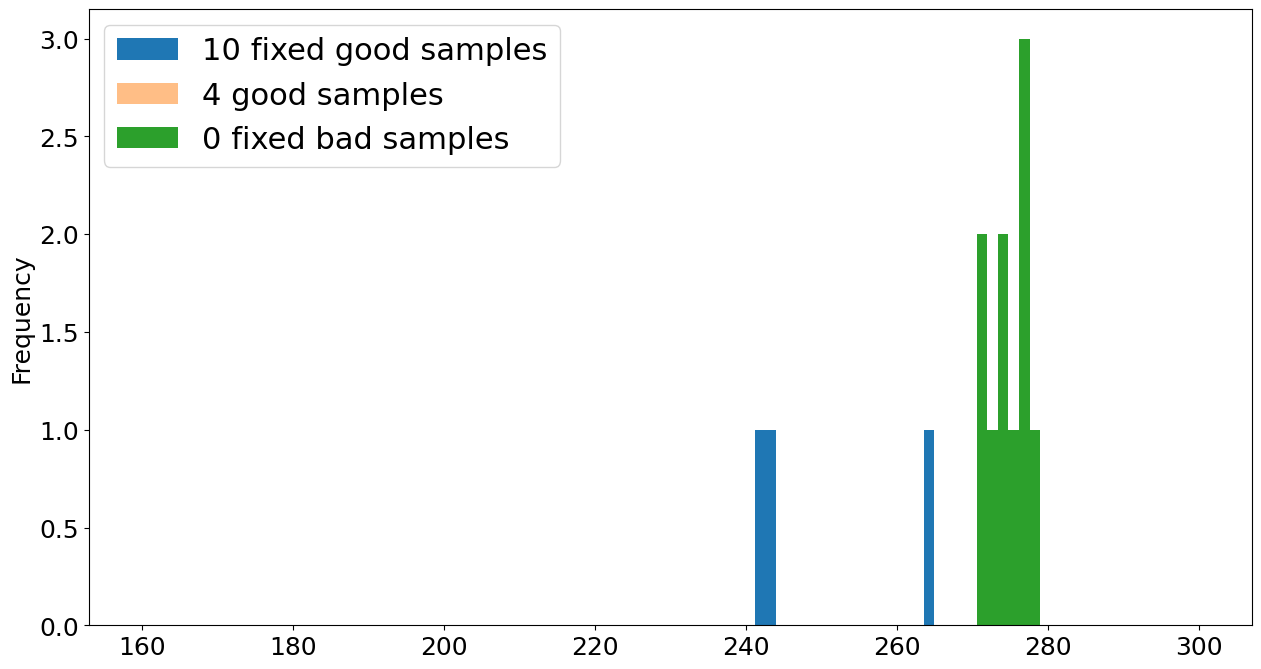

In [79]:
thebins = np.linspace(160, 300, 101)
ax = ev_fit_results_df.B_murn[indexofgoodsamples].plot.hist(bins=thebins)
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

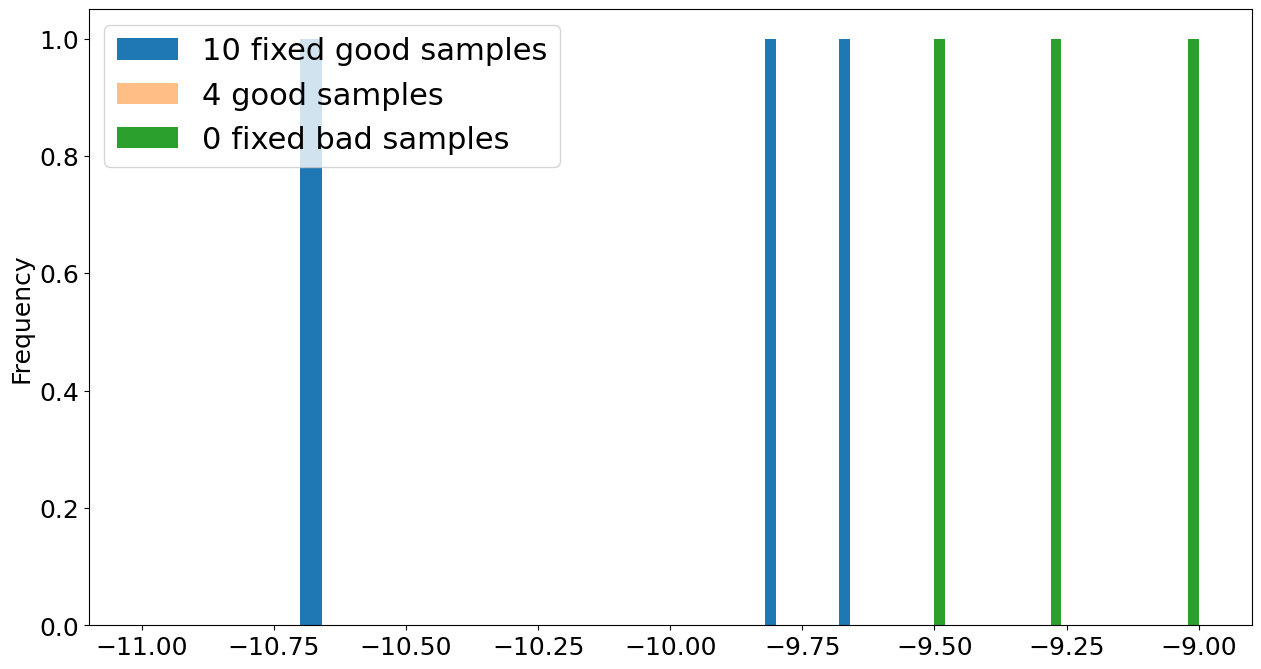

In [80]:
thebins = np.linspace(-11, -9, 101)
ax = ev_fit_results_df.E_murn[indexofgoodsamples].plot.hist(bins=thebins)
fixed_ev_fit_results_df.E_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
fixed_ev_fit_results_df.E_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

# redefine the new good BS

but now I need to correct the E0, B0 and V0 to the results of the fix !

In [81]:
fixedValidationBS['E0'].dropna()

Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM    -9.818704
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM    -9.673818
Mo_sv56.P.NM                      -10.689768
Mo_sv56.delta.NM                  -10.664102
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM    -9.492254
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM    -9.267087
Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM    -9.011284
Fe_pv40Mo_sv12.M-AAAAAAABABB.NM    -8.763571
Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM     -8.504437
Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM     -8.237145
Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM     -8.223871
Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM    -8.238914
Fe_pv56.P.NM                       -7.984777
Fe_pv56.delta.NM                   -8.023074
Name: E0, dtype: float64

In [82]:
fixedValidationBS.loc[indexoffixedgoodsamples,'E0'] = fixed_ev_fit_results_df['E_murn'][indexoffixedgoodsamples]
fixedValidationBS.loc[indexoffixedgoodsamples,'V0'] = fixed_ev_fit_results_df['V_murn'][indexoffixedgoodsamples]
fixedValidationBS.loc[indexoffixedgoodsamples,'B0'] = fixed_ev_fit_results_df['B_murn'][indexoffixedgoodsamples]
fixedValidationBS.dropna().describe()

,Mag,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,relax_volume,num_atoms,...,num_atom_B,E0,V0,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
fixedValidationBS.shape

(14, 39)

In [84]:
fixedValidationBS['E0']

Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM    -9.818704
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM    -9.673818
Mo_sv56.P.NM                      -10.689768
Mo_sv56.delta.NM                  -10.664102
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM    -9.492254
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM    -9.267087
Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM    -9.011284
Fe_pv40Mo_sv12.M-AAAAAAABABB.NM    -8.763571
Fe_pv44Mo_sv8.M-AAAAAAAAABB.NM     -8.504437
Fe_pv48Mo_sv4.M-AAAAAAAAAAB.NM     -8.237145
Fe_pv48Mo_sv4.M-AAAAAAAAABA.NM     -8.223871
Fe_pv52Mo_sv4.P-AAAAABAAAAAA.NM    -8.238914
Fe_pv56.P.NM                       -7.984777
Fe_pv56.delta.NM                   -8.023074
Name: E0, dtype: float64

In [85]:
import re

In [86]:
def get_phase_from_index(theindex):
    phaseconfig = theindex.split('.')[1]
    phase = phaseconfig.split('-')[0]
    return phase

In [87]:
fixedValidationBS['Phase'] = fixedValidationBS.index.map(get_phase_from_index)

# New data for delta using AMS tools

In [88]:
from ase import Atoms
import pandas as pd

In [89]:
import sys
import numpy.core as np_core
import numpy.core.numeric as np_numeric

# Compatibility shim for pickles written with NumPy internals under 'numpy._core'
sys.modules.setdefault('numpy._core', np_core)
sys.modules.setdefault('numpy._core.numeric', np_numeric)

_bs_w_r_path = 'Fe-Mo/inchulldft/BriefSummary.pkl.gz'
if os.path.exists(_bs_w_r_path):
    ValidationBS_delta = pd.read_pickle(_bs_w_r_path, compression='gzip')
else:
    ValidationBS_delta = None
    print('Fe-Mo/inchulldft/BriefSummary.pkl.gz not found — cells using ValidationBS_delta will be skipped.')

In [90]:
import re as _re

def _parse_atom_counts(name):
    """Parse Fe/Mo atom counts from AMS structure name string."""
    sample_id = name.split('/')[-3]
    fe = _re.search(r'Fe_pv(\d+)', sample_id)
    mo = _re.search(r'Mo_sv(\d+)', sample_id)
    return {'Fe': int(fe.group(1)) if fe else 0, 'Mo': int(mo.group(1)) if mo else 0}

if ValidationBS_delta is not None:
    num_atoms_delta = pd.DataFrame.from_dict(
        ValidationBS_delta['name'].map(_parse_atom_counts).to_dict(), orient='index'
    ).fillna(0)

In [91]:
# atom counts computed in cell above from name string

In [92]:
if ValidationBS_delta is not None:
    ValidationBS_delta = pd.concat([ValidationBS_delta, num_atoms_delta], axis=1)

In [93]:
def parse_name(thename):
    splittedname = thename.split('/')
    sample_id = splittedname[-3]
    sample_info = sample_id.split('.')
    return {'Mag': sample_info[-1], '' : sample_info[1], 'Phase' : sample_info[1].split('-')[0], 'sample_id': sample_id}

In [94]:
if ValidationBS_delta is not None:
    IDS = pd.DataFrame.from_dict(ValidationBS_delta.name.map(parse_name).to_dict(), orient='index')

In [95]:
if ValidationBS_delta is not None:
    ValidationBS_delta = pd.concat([IDS, ValidationBS_delta], axis=1)

In [96]:
if ValidationBS_delta is not None:
    ValidationBS_delta.set_index('sample_id', inplace=True)

In [97]:
if ValidationBS_delta is not None:
    ValidationBS_delta.columns

In [98]:
if ValidationBS_delta is not None:
    ValidationBS_delta.rename(columns={'murnaghan_equilibrium_bulk_modulus': 'B0', 'Fe': 'num_atom_A', 'Mo': 'num_atom_B', 'relax_n_atom': 'num_atoms'}, inplace=True)

In [99]:
if ValidationBS_delta is not None:
    ValidationBS_delta.columns

In [100]:
if ValidationBS_delta is not None:
    ValidationBS_delta['E0'] = ValidationBS_delta['murnaghan_equilibrium_energy']/ValidationBS_delta['num_atoms']
    ValidationBS_delta['V0'] = ValidationBS_delta['murnaghan_equilibrium_volume']/ValidationBS_delta['num_atoms']

In [101]:
if ValidationBS_delta is not None:
    ValidationBS_delta.head()['E0']

In [102]:
def get_n_atom(natoms):
    if natoms > 0:
        return 1
    return 0

In [103]:
if ValidationBS_delta is not None:
    #ValidationBS_delta['atom_A'] =
    ValidationBS_delta['atom_A'] = ValidationBS_delta['num_atom_A'].map(lambda a: get_n_atom(a)*'Fe_pv')

In [104]:
if ValidationBS_delta is not None:
    #ValidationBS_delta['atom_A'] =
    ValidationBS_delta['atom_B'] = ValidationBS_delta['num_atom_B'].map(lambda a: get_n_atom(a)*'Mo_sv')

In [105]:
fixedValidationBS.head()

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM,NaN,bulk M-ABBAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,263.925712 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,0.056906,0.384615,0.615385
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM,NaN,bulk M-BAAAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,271.174559 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,-0.009650,0.461538,0.538462
Mo_sv56.P.NM,NaN,bulk P,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,1,0.243053,1.000000,0.000000
Mo_sv56.delta.NM,NaN,bulk delta,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,241.895431 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,1,0.268719,1.000000,0.000000
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM,NaN,bulk M-AAAAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,276.932244 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,-0.039529,0.538462,0.461538


In [106]:
# Load complex TCP phase validation entries from ParsedBriefsummary.pkl (BOPfox-parsed DFT data)
# This covers R, P, M, delta phases — all not in training set
_parsed_bs_path = os.path.join(validation_dataset, 'ParsedBriefsummary.pkl')
ValidationBS_parsed = None
if os.path.exists(_parsed_bs_path):
    _all_parsed = pd.read_pickle(_parsed_bs_path)
    _all_parsed['Phase'] = _all_parsed.index.map(
        lambda x: x.split('.')[1].split('-')[0])
    _complex_phases = ['R', 'P', 'M', 'delta']
    _complex = _all_parsed[_all_parsed['Phase'].isin(_complex_phases)]
    _new = _complex.index.difference(BS.index)
    ValidationBS_parsed = _complex.loc[_new]
    print(f'Complex TCP entries from ParsedBriefsummary: {len(ValidationBS_parsed)}')
    print(ValidationBS_parsed["Phase"].value_counts().to_dict())
else:
    print(f'{_parsed_bs_path} not found — complex TCP entries will be omitted')

parts = [p for p in [ValidationBS_delta, fixedValidationBS, ValidationBS_parsed] if p is not None]
FullValidationBS = pd.concat(parts, axis=0)
# Drop duplicates (keep first occurrence)
FullValidationBS = FullValidationBS[~FullValidationBS.index.duplicated(keep='first')]

Complex TCP entries from ParsedBriefsummary: 53
{'R': 19, 'delta': 13, 'P': 12, 'M': 9}


In [107]:
FullValidationBS

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,B,fit,xc,encut,deltak,ncrash,nelem,EF,x_Fe,x_Mo
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,NM,delta-AAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/Fe/delta/Fe_pv56.del...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-448.707000,"[[0.00134237, -0.0009403500000000001, -0.00018...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM,NM,R-AAAAAABAABB,R,VASP_PBE_500_0.125_0.1_NM/FeMo/R/Fe_pv39Mo_sv1...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-471.893007,"[[0.0, 0.0, 0.0], [0.00065508, 0.00039792, 0.0...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM,NM,delta-BBAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv48Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 2...",-474.228176,"[[-0.00211024, 0.00027539000000000003, -0.0001...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM,NM,delta-BBBBBBBBAAABAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv20Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-554.893090,"[[0.00032864, 0.00115415, -0.00107401], [0.000...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NM,delta-AABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 4...",-462.560867,"[[-0.0008108400000000001, 0.00079078, -0.00207...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv6Mo_sv47.R-BBBBBBBBABB.NM,NaN,bulk R-BBBBBBBBABB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,232.000374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,NaN,NaN,NaN
Fe_pv8Mo_sv45.R-BABBBABBBBB.NM,NaN,bulk R-BABBBABBBBB,R,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,248.566042 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,NaN,NaN,NaN
Fe_pv8Mo_sv48.P-BBBBBBBBBBAB.NM,NaN,bulk P-BBBBBBBBBBAB,P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,251.998072 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,NaN,NaN,NaN
Fe_pv8Mo_sv48.delta-BBBBBBBBABBABB.NM,NaN,bulk delta-BBBBBBBBABBABB,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,250.595755 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.020,0,2.0,NaN,NaN,NaN


# Getting Formation Energies

In [108]:
from Tools.DatasetTools import ValidationSetNormalization as nv

In [109]:
ground_state_energies ={ ('Fe_pv','NM'): -8.18407186323532,
                       ('Mo_sv', 'NM'): -10.932821158319513,
                      }
# taken from ground_state_energies in notebook 03

In [110]:
normalizer = nv.briefsummary_normalizer(
    ground_states=ground_state_energies, init_bs=FullValidationBS, 
    atomA='Fe', atomB = 'Mo'
)

In [111]:
FullValidationBS['EF'] = normalizer.get_formation_energies()

In [112]:
FullValidationBS[[f'x_{normalizer.atomA}',f'x_{normalizer.atomB}' ]] = normalizer.get_atom_composition()

In [113]:
FullValidationBS.to_pickle(os.path.join(validation_dataset, 'ValidationFullyCuratedParsedBriefSummary.pkl'))

# saving to pickle

In [114]:
FullValidationBS.to_pickle(os.path.join(validation_dataset, 'ValidationFullyCuratedParsedBriefSummary.pkl'))

# Just a peak into the predictions

In [115]:
just_a_prediction = pd.read_csv('Fe-Mo/results/PREDICTION__R__0.7dprojections_0.5os_16.csv', index_col=0)

(array([ 14.,  64., 175., 336., 451., 452., 314., 175.,  49.,  18.]),
 array([-0.03191032,  0.01937849,  0.0706673 ,  0.12195611,  0.17324492,
         0.22453373,  0.27582254,  0.32711135,  0.37840016,  0.42968897,
         0.48097778]),
 <BarContainer object of 10 artists>)

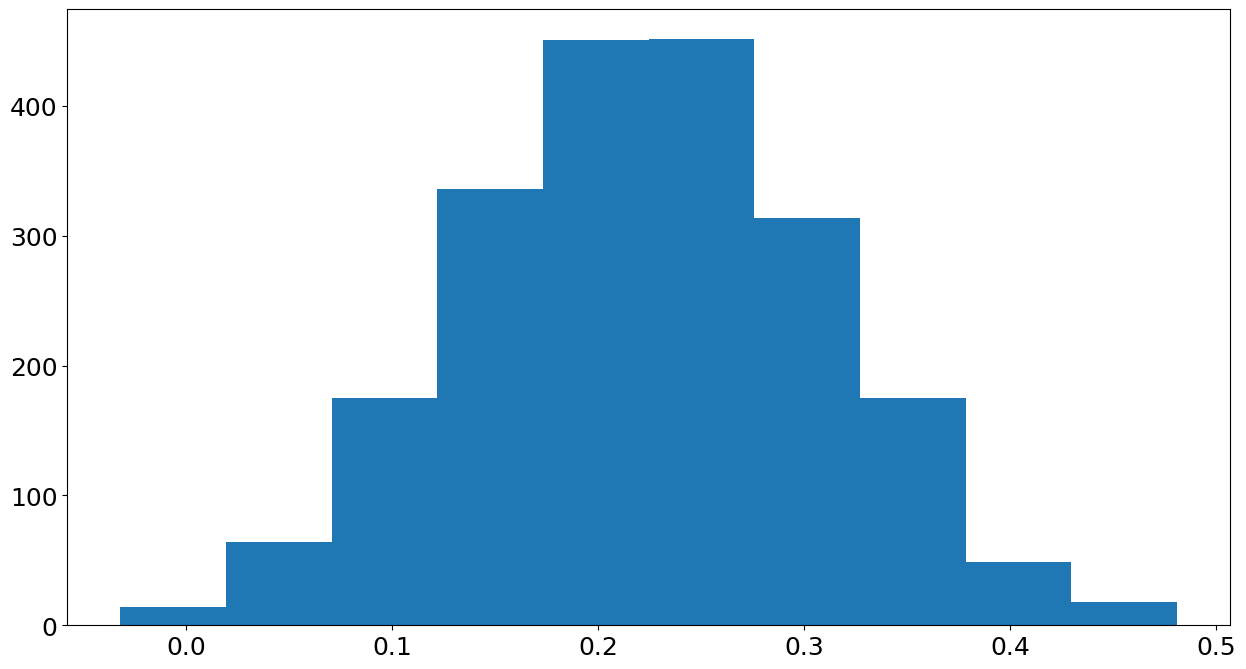

In [116]:
plt.hist(just_a_prediction['EF_nmhcp__0.7dprojections_0.5os'])

In [117]:
validation_R = FullValidationBS.query('index.str.contains("R")')

In [118]:
validated_predictions = validation_R.index.intersection(just_a_prediction.index)

In [119]:
validated_predictions.str.contains('AAAAAABAABB').sum()

np.int64(1)

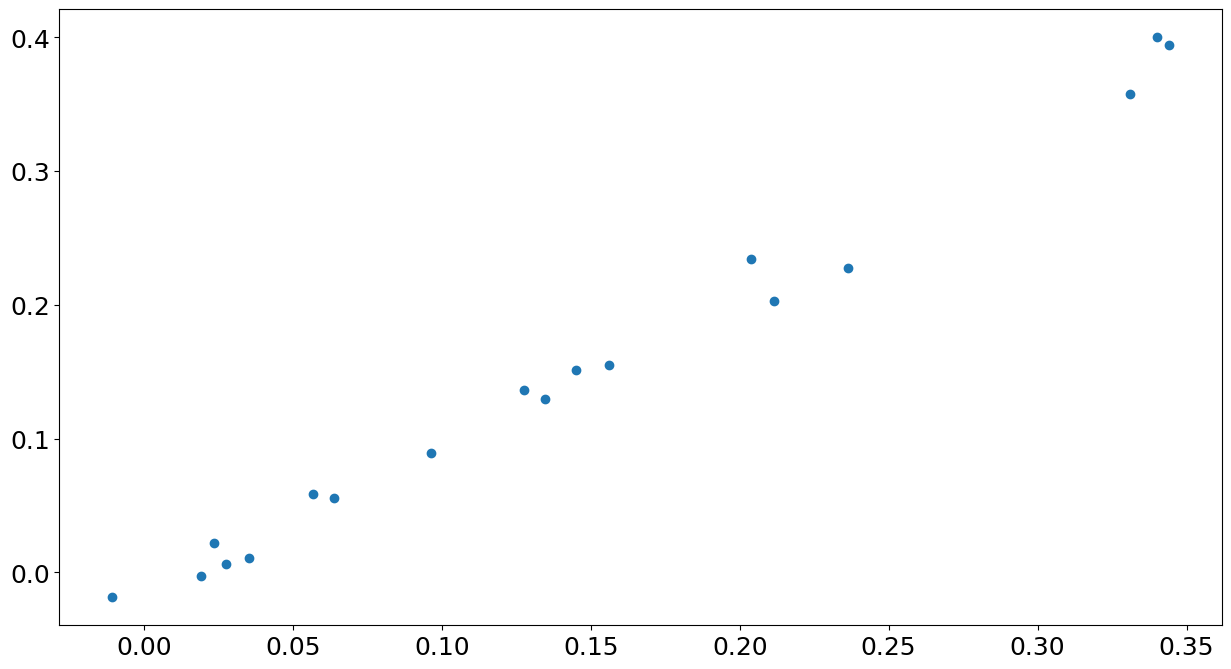

In [120]:
plt.scatter(
    just_a_prediction['EF_nmhcp__0.7dprojections_0.5os'].loc[validated_predictions], 
    FullValidationBS.loc[validated_predictions]['EF']
)

In [121]:
from sklearn.metrics import mean_squared_error

In [122]:
#mean_squared_error(
#    validationBS['EF'][validated_predictions], just_a_prediction['EF_nmhcp__0.7dprojections_0.5os'][validated_predictions],
#    squared=False
#)